# Student Performance Analysis and Writing Score Prediction

## Project Overview

This project explores how selected student background factors relate to exam performance and compares two linear regression approaches for predicting writing scores.

1. **Background-factor model:** lunch type, test preparation, and parental education
2. **Academic-indicator model:** math and reading scores

The goal is not to claim causation, but to evaluate how much predictive information each group of variables provides.

## Data Source

This notebook uses the **Students Performance in Exams** dataset published on Kaggle by Jakki Seshapanpu.

- Dataset page: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams
- Expected local path: `data/StudentsPerformance.csv`

The Kaggle listing labels the license as **Unknown**, so the CSV file is not included in this repository. Download it directly from Kaggle before running the notebook.

## Research Questions

- How do average exam scores differ across lunch and test-preparation groups?
- How strongly are math, reading, and writing scores correlated?
- How well do selected background factors predict writing scores?
- How much does prediction improve when related academic scores are used?

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

Matplotlib is building the font cache; this may take a moment.


## 1. Load and Inspect the Data

In [2]:
data_path = Path("data/StudentsPerformance.csv")
images_dir = Path("images")
images_dir.mkdir(exist_ok=True)

if not data_path.exists():
    raise FileNotFoundError(
        "StudentsPerformance.csv was not found. "
        "Download it from the Kaggle link in README.md and save it as "
        "data/StudentsPerformance.csv."
    )

df = pd.read_csv(data_path)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
display(df.isna().sum().rename("Missing values"))

Rows: 1,000
Columns: 8


gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writing score                  0
Name: Missing values, dtype: int64

The dataset contains student background categories and math, reading, and writing scores. It does not include direct personal identifiers, and no missing values are present in the provided file.

## 2. Exploratory Data Analysis

In [3]:
score_columns = ["math score", "reading score", "writing score"]

display(df[score_columns].describe().round(2))

mean_by_lunch = df.groupby("lunch")[score_columns].mean().round(2)
mean_by_prep = df.groupby("test preparation course")[score_columns].mean().round(2)

print("Average scores by lunch type")
display(mean_by_lunch)

print("Average scores by test preparation")
display(mean_by_prep)

,math score,reading score,writing score
count,1000.00,1000.00,1000.00
mean,66.09,69.17,68.05
std,15.16,14.60,15.20
min,0.00,17.00,10.00
25%,57.00,59.00,57.75
50%,66.00,70.00,69.00
75%,77.00,79.00,79.00
max,100.00,100.00,100.00


Average scores by lunch type


,math score,reading score,writing score
lunch,,,
free/reduced,58.92,64.65,63.02
standard,70.03,71.65,70.82


Average scores by test preparation


,math score,reading score,writing score
test preparation course,,,
completed,69.70,73.89,74.42
none,64.08,66.53,64.50


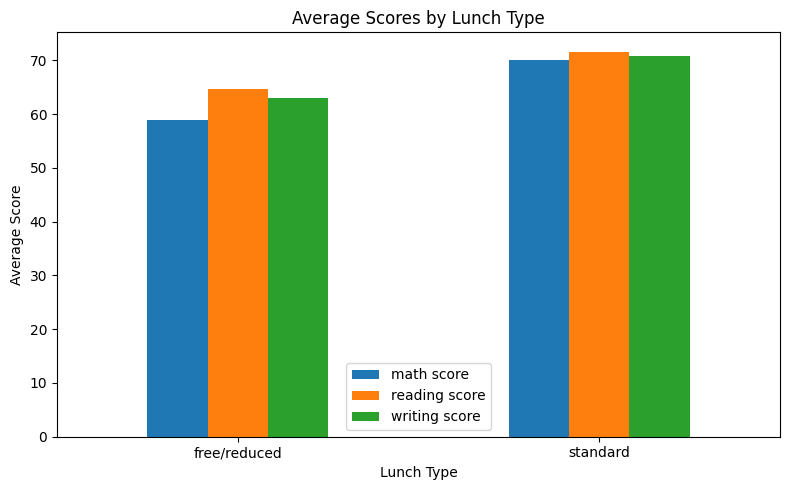

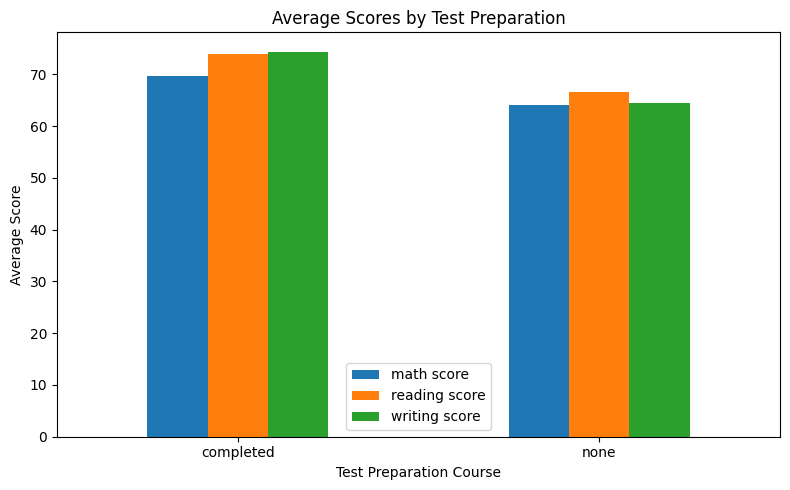

In [4]:
mean_by_lunch.plot(kind="bar", figsize=(8, 5))
plt.title("Average Scores by Lunch Type")
plt.xlabel("Lunch Type")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

mean_by_prep.plot(kind="bar", figsize=(8, 5))
plt.title("Average Scores by Test Preparation")
plt.xlabel("Test Preparation Course")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

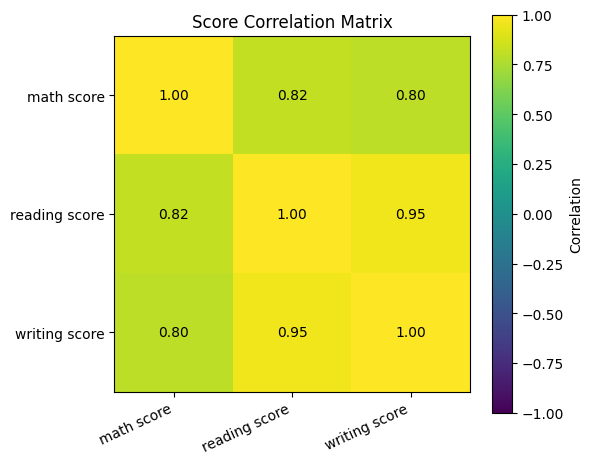

In [5]:
correlation = df[score_columns].corr()

fig, ax = plt.subplots(figsize=(6, 5))
image = ax.imshow(correlation.values, vmin=-1, vmax=1)

ax.set_xticks(range(len(correlation.columns)), correlation.columns, rotation=25, ha="right")
ax.set_yticks(range(len(correlation.index)), correlation.index)

for i in range(len(correlation.index)):
    for j in range(len(correlation.columns)):
        ax.text(j, i, f"{correlation.iloc[i, j]:.2f}", ha="center", va="center")

fig.colorbar(image, ax=ax, label="Correlation")
ax.set_title("Score Correlation Matrix")
plt.tight_layout()
plt.savefig(images_dir / "score_correlation.png", dpi=150, bbox_inches="tight")
plt.show()

The three test scores are strongly correlated. This suggests that math and reading scores may contain much more predictive information about writing performance than the selected background variables.

## 3. Model 1: Background Factors

In [6]:
target = "writing score"
background_features = [
    "lunch",
    "test preparation course",
    "parental level of education",
]

X_background = df[background_features]
y = df[target]

X_train_bg, X_test_bg, y_train_bg, y_test_bg = train_test_split(
    X_background,
    y,
    test_size=0.2,
    random_state=42,
)

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(drop="first", handle_unknown="ignore"),
            background_features,
        )
    ]
)

background_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression()),
    ]
)

background_model.fit(X_train_bg, y_train_bg)
background_predictions = background_model.predict(X_test_bg)

background_results = {
    "R²": r2_score(y_test_bg, background_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_bg, background_predictions)),
    "MAE": mean_absolute_error(y_test_bg, background_predictions),
}

pd.Series(background_results).round(3)

R²       0.181
RMSE    14.049
MAE     10.842
dtype: float64

The background-factor model has limited predictive power:

- **R²:** 0.181
- **RMSE:** 14.05
- **MAE:** 10.84

These variables are associated with score differences, but they do not explain most of the variation in writing scores.

## 4. Model 2: Academic Indicators

In [7]:
academic_features = ["math score", "reading score"]

X_academic = df[academic_features]

X_train_ac, X_test_ac, y_train_ac, y_test_ac = train_test_split(
    X_academic,
    y,
    test_size=0.2,
    random_state=42,
)

academic_model = LinearRegression()
academic_model.fit(X_train_ac, y_train_ac)
academic_predictions = academic_model.predict(X_test_ac)

academic_results = {
    "R²": r2_score(y_test_ac, academic_predictions),
    "RMSE": np.sqrt(mean_squared_error(y_test_ac, academic_predictions)),
    "MAE": mean_absolute_error(y_test_ac, academic_predictions),
}

pd.Series(academic_results).round(3)

R²      0.902
RMSE    4.865
MAE     3.838
dtype: float64

In [8]:
coefficient_table = pd.DataFrame(
    {
        "Feature": academic_features,
        "Coefficient": academic_model.coef_,
    }
)

display(coefficient_table.round(3))
print(f"Intercept: {academic_model.intercept_:.3f}")

,Feature,Coefficient
0,math score,0.070
1,reading score,0.937


Intercept: -1.432


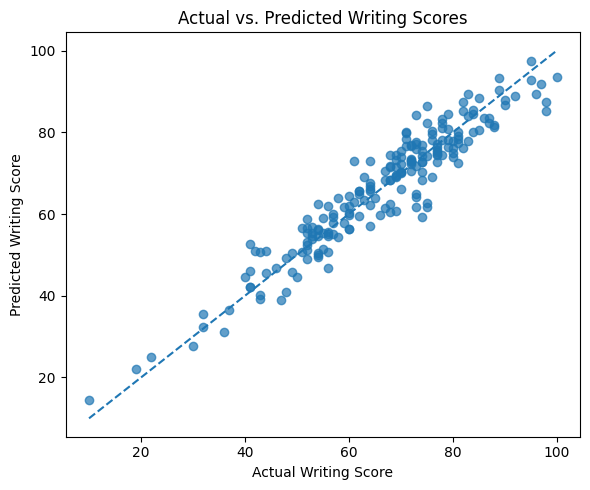

In [9]:
plt.figure(figsize=(6, 5))
plt.scatter(y_test_ac, academic_predictions, alpha=0.7)

line_min = min(y_test_ac.min(), academic_predictions.min())
line_max = max(y_test_ac.max(), academic_predictions.max())
plt.plot([line_min, line_max], [line_min, line_max], linestyle="--")

plt.xlabel("Actual Writing Score")
plt.ylabel("Predicted Writing Score")
plt.title("Actual vs. Predicted Writing Scores")
plt.tight_layout()
plt.savefig(images_dir / "actual_vs_predicted.png", dpi=150, bbox_inches="tight")
plt.show()

The academic-indicator model performs substantially better:

- **R²:** 0.902
- **RMSE:** 4.86
- **MAE:** 3.84

Because math, reading, and writing scores measure related academic skills, this model is useful for prediction but should not be interpreted as evidence that one score causes another.

## 5. Model Comparison

,Model,R²,RMSE,MAE
0,Background factors,0.181,14.049,10.842
1,Academic indicators,0.902,4.865,3.838


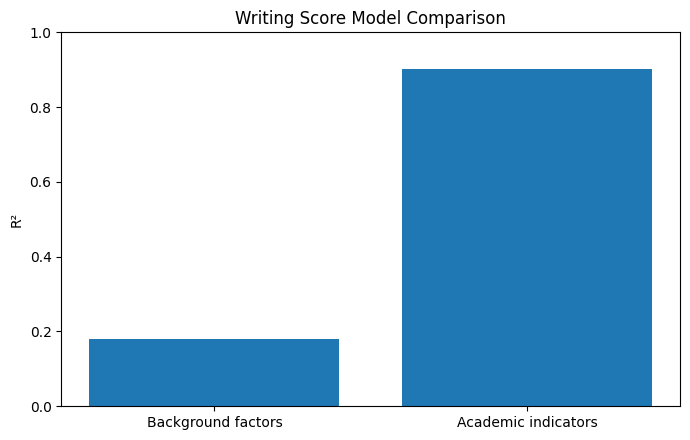

In [10]:
comparison = pd.DataFrame(
    {
        "Model": ["Background factors", "Academic indicators"],
        "R²": [background_results["R²"], academic_results["R²"]],
        "RMSE": [background_results["RMSE"], academic_results["RMSE"]],
        "MAE": [background_results["MAE"], academic_results["MAE"]],
    }
)

display(comparison.round(3))

plt.figure(figsize=(7, 4.5))
plt.bar(comparison["Model"], comparison["R²"])
plt.ylabel("R²")
plt.title("Writing Score Model Comparison")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(images_dir / "model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Responsible Use

- This analysis is for educational and portfolio purposes.
- The models should not be used for high-stakes educational decisions.
- Gender and race/ethnicity are not used as predictors.
- The academic-indicator model uses related scores from the same exam context and is not an early-warning model.

## Conclusion

- Lunch type, test preparation, and parental education show some relationship with student outcomes, but their combined predictive power is limited.
- Math and reading scores provide substantially stronger predictive information for writing scores.
- The project demonstrates an iterative modeling process: an initial background-variable model was evaluated, its limitations were identified, and a stronger model was developed using more relevant predictors.
- The results describe associations within this dataset and should not be interpreted as causal conclusions.

## Limitations

- The dataset does not include attendance, study time, school characteristics, or prior-year grades.
- The writing-score model uses scores from related exams taken in the same context, so it is not an early-warning model.
- Results may not generalize to other schools or student populations.